In [1]:
%pip install tensorflow
%pip install scikit-learn
%pip install keras

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Facial Recognition Demo with Keras
# Dataset: LFW - Labeled Faces in the Wild

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.utils import to_categorical

In [3]:
# 1. Load dataset
lfw_people = fetch_lfw_people(
    min_faces_per_person=70,
    resize=0.4,
    color=True
)

X = lfw_people.images
y = lfw_people.target
target_names = lfw_people.target_names

print("Images:", X.shape)
print("Classes:", target_names)

Images: (1288, 50, 37, 3)
Classes: ['Ariel Sharon' 'Colin Powell' 'Donald Rumsfeld' 'George W Bush'
 'Gerhard Schroeder' 'Hugo Chavez' 'Tony Blair']


In [18]:
# 2. Preprocess images

# Resize images
X_resized = tf.image.resize(X, (160, 160)).numpy().astype("float32")

# No division by 255 needed
print(X_resized.min(), X_resized.max())

# One-hot encode labels
num_classes = len(target_names)
y_cat = to_categorical(y, num_classes)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_resized,
    y_cat,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

0.0 1.0
Training data: (966, 160, 160, 3)
Testing data: (322, 160, 160, 3)


In [19]:
print(X_resized.min(), X_resized.max())

0.0 1.0


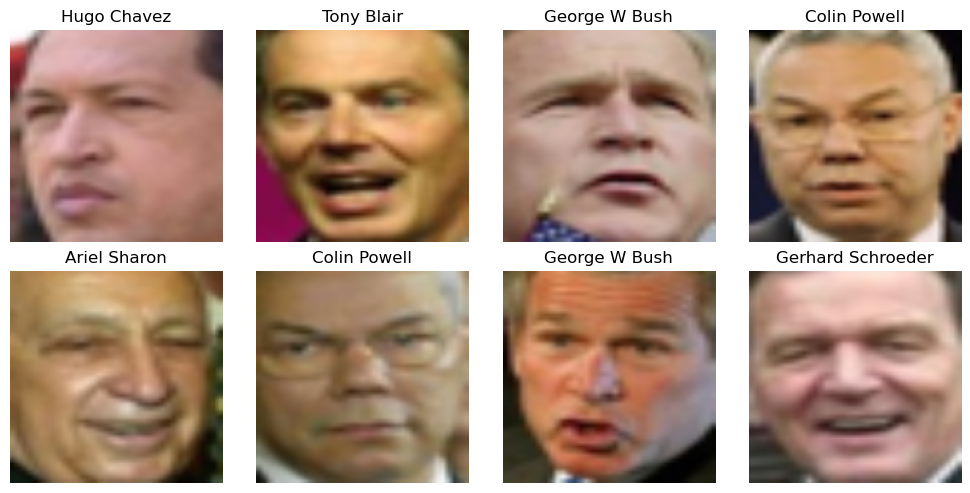

In [21]:
# 3. Visualize sample images

plt.figure(figsize=(10, 5))

for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(X_resized[i])
    plt.title(target_names[y[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [22]:
# 4. Build transfer learning model

base_model = MobileNetV2(
    input_shape=(160, 160, 3),
    include_top=False,
    weights="imagenet"
)

# Freeze pretrained layers
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,855 (9.24 MB)

 Trainable params: 164,871 (644.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [23]:
# 5. Train model

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32
)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 104ms/step - accuracy: 0.3679 - loss: 1.9049 - val_accuracy: 0.6753 - val_loss: 1.2403
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - accuracy: 0.5648 - loss: 1.2279 - val_accuracy: 0.7010 - val_loss: 0.9714
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - accuracy: 0.6554 - loss: 1.0022 - val_accuracy: 0.7732 - val_loss: 0.8372
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - accuracy: 0.7137 - loss: 0.8515 - val_accuracy: 0.8093 - val_loss: 0.7307
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - accuracy: 0.7435 - loss: 0.7343 - val_accuracy: 0.8041 - val_loss: 0.6819
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - accuracy: 0.8070 - loss: 0.6251 - val_accuracy: 0.7887 - val_loss: 0.6863
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - accuracy: 0.7927 - loss: 0.6014 - val_accuracy: 0.8299 - val_loss: 0.5713
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - accuracy: 0.8225 - loss: 0.5024 - val_accuracy: 0.8041 - 

In [24]:
# 6. Evaluate model

test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test accuracy:", test_accuracy)
print("Test loss:", test_loss)

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.8323 - loss: 0.5090
Test accuracy: 0.8322981595993042
Test loss: 0.5090456008911133


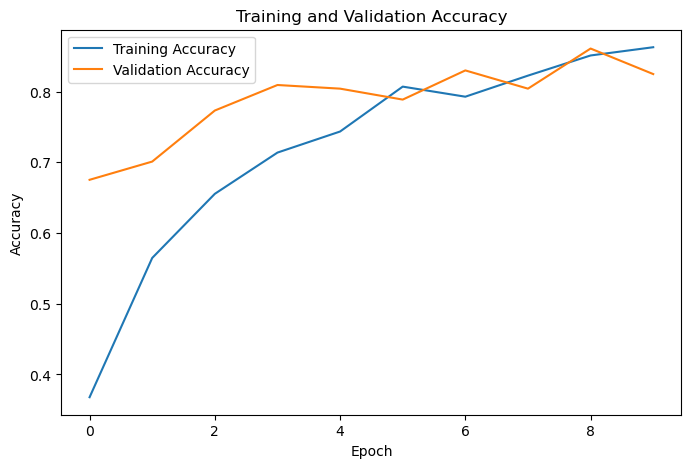

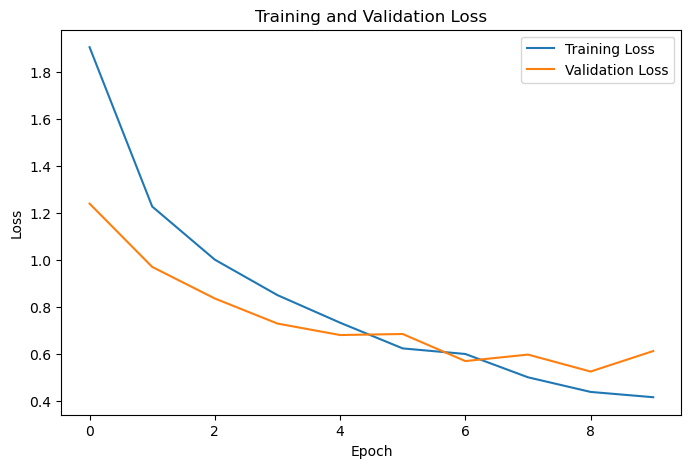

In [25]:
# 7. Plot training curves

plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

In [26]:
# 8. Classification report

y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

print(classification_report(
    y_true,
    y_pred,
    target_names=target_names
))

11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 110ms/step
                   precision    recall  f1-score   support

     Ariel Sharon       0.94      0.79      0.86        19
     Colin Powell       0.96      0.86      0.91        59
  Donald Rumsfeld       0.89      0.83      0.86        30
    George W Bush       0.79      0.96      0.86       133
Gerhard Schroeder       1.00      0.41      0.58        27
      Hugo Chavez       0.86      0.33      0.48        18
       Tony Blair       0.73      0.89      0.80        36

         accuracy                           0.83       322
        macro avg       0.88      0.73      0.76       322
     weighted avg       0.85      0.83      0.82       322



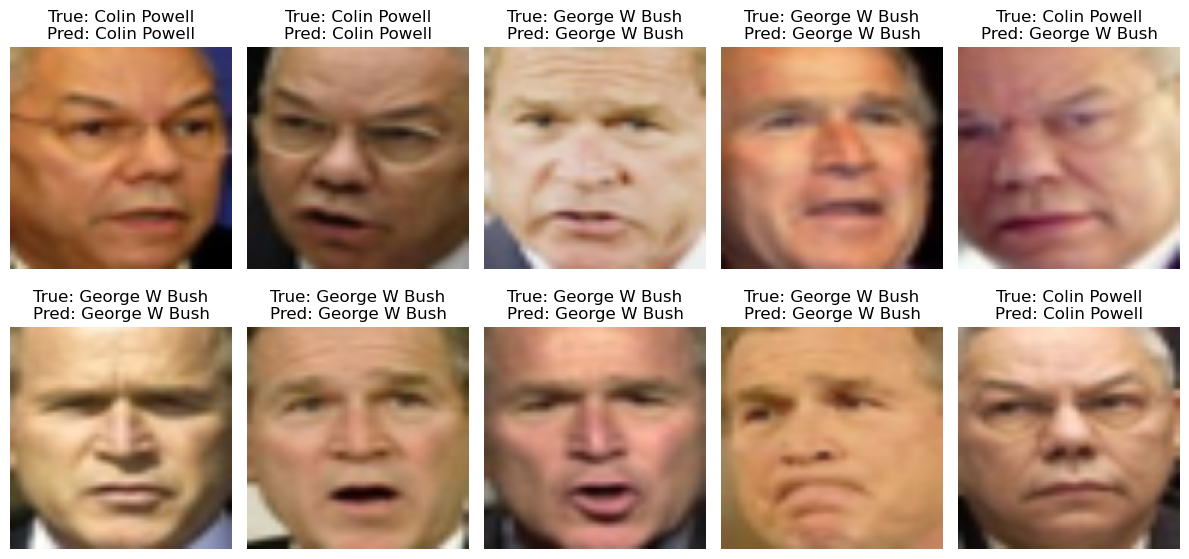

In [27]:
# 9. Show prediction examples

plt.figure(figsize=(12, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[i])
    
    true_label = target_names[y_true[i]]
    predicted_label = target_names[y_pred[i]]
    
    plt.title(f"True: {true_label}\nPred: {predicted_label}")
    plt.axis("off")

plt.tight_layout()
plt.show()